In [14]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from pathlib import Path

In [15]:
train_image_path = Path('./data/Train')
test_image_path = Path('./data/Test')

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(root=train_image_path, transform = transform)
test_dataset = datasets.ImageFolder(root=test_image_path, transform = transform)

In [16]:
image_classes = train_dataset.classes
classes_dict = train_dataset.class_to_idx

print(image_classes)
print(classes_dict)

['Healthy', 'Powdery', 'Rust']
{'Healthy': 0, 'Powdery': 1, 'Rust': 2}


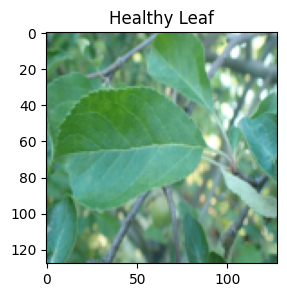

In [20]:
import matplotlib.pyplot as plt
import random as rn

index = rn.randint(0, len(train_dataset))
X, y = train_dataset[index]
plt.figure(figsize=(3, 3))
plt.imshow(X.permute(1, 2, 0))
plt.title(f"{image_classes[y]} Leaf")
plt.show()

In [21]:
BATCH_SIZE = 32
train_dataloader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
test_dataloader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = True)

In [22]:
X, y = next(iter(train_dataloader))
X[0]

tensor([[[0.3529, 0.3961, 0.4510,  ..., 0.4627, 0.4941, 0.5373],
         [0.3686, 0.3647, 0.4235,  ..., 0.4863, 0.5098, 0.5451],
         [0.4118, 0.3804, 0.4078,  ..., 0.4941, 0.5137, 0.5451],
         ...,
         [0.6196, 0.6039, 0.5765,  ..., 0.5098, 0.4980, 0.4784],
         [0.6078, 0.5882, 0.5608,  ..., 0.5020, 0.4863, 0.4706],
         [0.5922, 0.5725, 0.5569,  ..., 0.4902, 0.4745, 0.4549]],

        [[0.4157, 0.4706, 0.5255,  ..., 0.5647, 0.5961, 0.6431],
         [0.4314, 0.4431, 0.5020,  ..., 0.5882, 0.6118, 0.6471],
         [0.4627, 0.4431, 0.4784,  ..., 0.5961, 0.6157, 0.6471],
         ...,
         [0.4706, 0.4588, 0.4431,  ..., 0.5686, 0.5725, 0.5686],
         [0.4627, 0.4471, 0.4314,  ..., 0.5569, 0.5569, 0.5529],
         [0.4549, 0.4392, 0.4235,  ..., 0.5490, 0.5412, 0.5333]],

        [[0.2941, 0.3412, 0.4039,  ..., 0.4039, 0.4549, 0.4902],
         [0.3020, 0.3059, 0.3725,  ..., 0.4471, 0.4745, 0.5020],
         [0.3412, 0.3176, 0.3412,  ..., 0.4510, 0.4824, 0.

In [30]:
from torch import nn
from tqdm.auto import tqdm

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

class cnn_module(nn.Module):
    def __init__(self, in_channels = 3,
                 conv_layers = 1,
                 nos_feature_map_per_layer = 1,
                 kernel_size = 3,
                 pooling_kernel_size = 2, 
                 hidden_mlp_layers = 1,
                 nos_neuron_per_layer = 5):
        super().__init__()
        self.__in_channels = in_channels
        self.__convolution_layers = conv_layers
        self.__nos_of_feature_map_per_layer = nos_feature_map_per_layer
        self.__kernel_size = kernel_size
        self.__pooling_kernel_size = pooling_kernel_size
        self.__hidden_mlp_layers = hidden_mlp_layers
        self.__nos_neuron_per_layer = nos_neuron_per_layer

        self.__epochs = 5
        self.__learning_rate = 0.01

        self.__convolution_layer_list = nn.ModuleList()
        self.__mlp_layer_list = nn.ModuleList()

        self.cost_list = []

        self.__initialize_convolution_layer()

    def __initialize_convolution_layer(self):
        # process between input layer to first convolution layer
        self.__convolution_layer_list.append(
            nn.Sequential(
                nn.Conv2d(in_channels = self.__in_channels, 
                          out_channels = self.__nos_of_feature_map_per_layer, 
                          kernel_size = self.__kernel_size,
                          padding = 1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size = self.__pooling_kernel_size)
            )
        )

        for _ in range(1, self.__convolution_layers):
            self.__convolution_layer_list.append(
                nn.Sequential(
                    nn.Conv2d(in_channels = self.__nos_of_feature_map_per_layer, 
                            out_channels = self.__nos_of_feature_map_per_layer, 
                            kernel_size = self.__kernel_size,
                            padding = 1),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size = self.__pooling_kernel_size)
                )
            )
        # for flattening the feature map
        self.__convolution_layer_list.append(nn.Flatten())

    def __forwardpass_convolution(self, x):
        for layers in self.__convolution_layer_list:
            x = layers(x)
        return x

    def __initialize_mlp_weights(self, input_size, output_size):
        # input layer to first hidden layer
        self.__mlp_layer_list.append(nn.Linear(in_features = input_size, out_features = self.__nos_neuron_per_layer))

        for _ in range(1, self.__hidden_mlp_layers):
            self.__mlp_layer_list.append(nn.Linear(in_features = self.__nos_neuron_per_layer, out_features = self.__nos_neuron_per_layer))

        self.__output_layer = nn.Linear(in_features = self.__nos_neuron_per_layer, out_features = output_size)

    def __forwardpass_mlp(self, x):
        activation = nn.ReLU()
        for layer in self.__mlp_layer_list:
            z = layer(x)
            x = activation(z)
        x = self.__output_layer(x)
        return x

    def forward(self, x):
        x = self.__forwardpass_convolution(x)
        x = self.__forwardpass_mlp(x)
        return x
    
    def fit(self, train_dataloader, output_size, epochs = 5, lr = 0.01):
        self.__epochs = epochs
        self.__learning_rate = lr

        X, y = next(iter(train_dataloader))
        dummy_tensor = self.__forwardpass_convolution(X)

        input_size = dummy_tensor.shape[1]

        self.__initialize_mlp_weights(input_size, output_size)
        self.__loss_fn = nn.CrossEntropyLoss() 
        self.__optimiser = torch.optim.Adam(params = self.parameters(), lr = self.__learning_rate)

        for _ in tqdm(range(self.__epochs)):
            epoch_loss = 0
            for X, y in train_dataloader:
                self.train()
                y_pred = self(X)

                loss = self.__loss_fn(y_pred, y)
                epoch_loss += loss.item()

                self.__optimiser.zero_grad()
                loss.backward()
                self.__optimiser.step()

            epoch_loss /= len(train_dataloader)
            self.cost_list.append(epoch_loss)

    def predict(self, X):
        self.eval()
        with torch.inference_mode():
            raw_logits = self(X)
        y = raw_logits.argmax(dim = 1)
        return y

100%|██████████| 20/20 [4:01:08<00:00, 723.43s/it]   


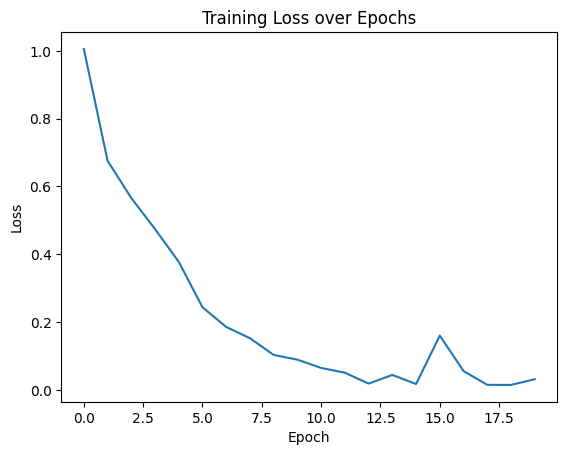

In [35]:
model = cnn_module(in_channels=3, conv_layers=3, hidden_mlp_layers=3, nos_feature_map_per_layer=32, nos_neuron_per_layer=256)
model.fit(train_dataloader=train_dataloader, output_size=3, epochs=20, lr=0.001)
import matplotlib.pyplot as plt
plt.plot(model.cost_list)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [36]:
X, y = next(iter(test_dataloader))
y_p = model.predict(X)

In [37]:
accuracy_fn(y, y_p)

87.5

In [38]:
y_p

tensor([1, 1, 0, 1, 1, 2, 0, 0, 1, 2, 2, 0, 1, 0, 0, 2, 0, 2, 0, 2, 1, 0, 2, 2,
        0, 1, 2, 2, 2, 1, 2, 0])

In [39]:
y

tensor([1, 1, 0, 1, 1, 2, 0, 0, 1, 2, 2, 0, 1, 1, 2, 2, 2, 2, 0, 2, 1, 0, 2, 2,
        2, 1, 2, 2, 2, 1, 2, 0])